```
Copyright (c) 2024-2025 National Institute of Advanced Industrial Science and Technology (AIST)
All rights reserved.
This software is released under the MIT License.
http://opensource.org/licenses/mit-license.php
```

## Introduction
In this notebook you will learn the basic use of the ef_capture.

1. [Records the transmitted and received timestamps of a 1 output, 1 input configuration](#1.-Records-the-transmitted-and-received-timestamps-of-a-1-output,-1-input-configuration)
   1. [Make initial settings](#1-A.-Make-initial-settings)
   2. [Set up the AXIS Switch](#1-B.-Set-up-the-AXIS-Switch)
   4. [Set up the ef_capture](#1-C.-Set-up-the-ef_capture)
   5. [Prepare send frames](#1-D.-Prepare-send-frames)
   6. [Send the frames from Port0 to Port1, in repeat mode](#1-E.-Send-the-frames-from-Port0-to-Port1,-in-repeat-mode)
   7. [Transfer the recorded timestamps to the host computer](#1-F.-Transfer-the-recorded-timestamps-to-the-host-computer)
   8. [Check the recorded timestamps](#1-G.-Check-the-recorded-timestamps)
   9. [Evaluate latency and throughput](#1-H.-Evaluate-latency-and-throughput)
   10. [Add offset to timestamps](#1-I.-Add-offset-to-timestamps)

In [4]:
import argparse
import tsn_efcc
import pyxsdb
import sys
import ipywidgets as widgets
from IPython.display import Markdown, display, Image

FREQ_MHZ = 156.25

# First, select the network configuration to use using the following radio buttons.
# If the ports are connected directly with a cable, select `loopback`. If they are connected via a network switch, select `with_switch`.

In [5]:
w = widgets.RadioButtons(description='Configuration:', options=['loopback', 'with_switch'])
display(w)

RadioButtons(description='Configuration:', options=('loopback', 'with_switch'), value='loopback')

# Be sure to execute the following cell after making your selection.

In [6]:
configuration = w.value
print(configuration)

with_switch


## 1. Records the transmitted and received timestamps of a 1 output, 1 input configuration

Connect TSN-EFCC ports 0 (MAC0) and 4 (MAC4) with an Ethernet cable.

Alternatively, connect ports 0 (MAC0) and 4 (MAC4) to a network switch.

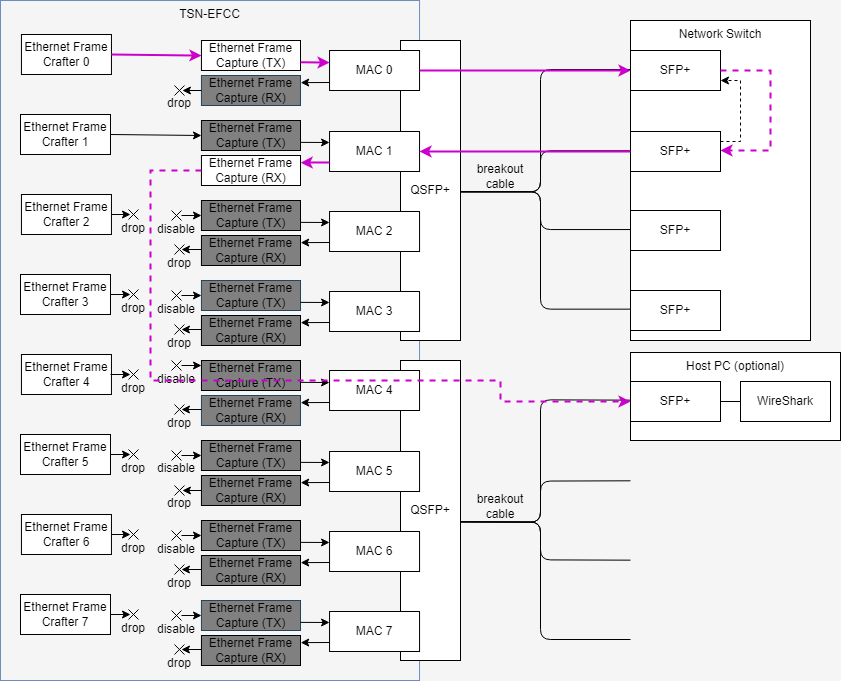

In [7]:
if configuration == 'with_switch':
  display(Markdown('Connect TSN-EFCC ports 0 (MAC0) and 4 (MAC4) with an Ethernet cable.'))
  display(Markdown('Alternatively, connect ports 0 (MAC0) and 4 (MAC4) to a network switch.'))
  display(Image(filename='img/overwiew_sample_design-10g_example_configuration2.drawio.png', embed=True))
else:
  display(Markdown('**If a network switch is not available, use a QSFP+ cable to create a loopback. However, the output to the Host PC cannot be used.**  '))
  display(Markdown('**In this case, set `PORT_RX` to `PORT_TX + 4`.**  '))
  display(Image(filename='img/overwiew_sample_design-10g_example_configuration2_cableloopback.drawio.png', embed=True))

### 1-A. Make initial settings

Set JTAG2AXI target. As default, this target is expected to be target 5.  
If you want to different target value, change the next value.

In [8]:
xsdb_target = 5

if configuration == 'with_switch':
    PORT_TX=0
    PORT_RX=1
    # PORT_HOST=4   # optional
else:
    # Settings for cable loopback configuration
    PORT_TX=0
    PORT_RX=(PORT_TX+4) % 8

In [9]:
# Open xsdb device to access TSN-EFCC
xsdb = pyxsdb.PyXsdb()
xsdb.connect()
xsdb.target(xsdb_target)

# Get the default address table object
default_addr_table = tsn_efcc.default_tsn_efcc_address_table_10g()
print(f'{default_addr_table}\n')

# Get the default config table object
default_config_table = tsn_efcc.default_axis_switch_config_table_10g()
print(f'{default_config_table}\n')

# Initialize AxisNetSwitch object
switch = tsn_efcc.AxisNetSwitch(xsdb, xsdb_target, default_addr_table, default_config_table)

# Initialize the ef_crafter
crafter = tsn_efcc.EFCrafter(xsdb, xsdb_target, default_addr_table)

# Just to be sure, stop ef_crafter
crafter.reset(0xff)

xsdb server launched.
TsnEfccAddressTable(ef_crafter=1593835520, ef_crafter_buffers=(1342177280, 1358954496, 1375731712, 1392508928, 1343225856, 1360003072, 1376780288, 1393557504), ef_crafter_ip_tables=(1409286144, 1426063360, 1442840576, 1459617792, 1410334720, 1427111936, 1443889152, 1460666368), ef_crafter_mac_tables=(1476395008, 1493172224, 1509949440, 1526726656, 1477443584, 1494220800, 1510998016, 1527775232), ef_capture_tx_ctrl=(1325400064, 1325465600, 1325531136, 1325596672, 1325662208, 1325727744, 1325793280, 1325858816), ef_capture_rx_ctrl=(1325432832, 1325498368, 1325563904, 1325629440, 1325694976, 1325760512, 1325826048, 1325891584), ef_capture_buffers=(1073741824, 1090519040, 1107296256, 1124073472, 1140850688, 1157627904, 1174405120, 1191182336, 1082130432, 1098907648, 1115684864, 1132462080, 1149239296, 1166016512, 1182793728, 1199570944), ef_capture_buffer_switch=(1326448640, 1326514176, 1326579712, 1326645248), axis_net_switch=(1610612736, 1610616832), commit_hash=104

To be on the safe side, update the look-up table (LUT) so that the MAC address and IP address are different from those of the NIC.

In [10]:
macbase = 'aa:bb:cc:dd:ee:'
ipbase = '192.168.11.'
for i in range(8):
    for j in range(8):
        macstr = macbase + "{:02x}".format(j+1)
        ipstr = ipbase + str(j+1)
        crafter.set_mac_address(port=i, index=j+1, val=macstr)
        crafter.set_ip_address(port=i, index=j+1, val=ipstr)

### 1-B. Set up the AXIS Switch

In [11]:
print(f'In this test, we connect EFCrafter0(port 8) to TX{PORT_TX}(port {PORT_TX}).')
print(f'In addition, EFCrafter1 (port 9) is connected to TX{PORT_RX} (port {PORT_RX}) for FDB learning when using a switch.')
print('Other input ports are disconnected from output port.')

In this test, we connect EFCrafter0(port 8) to TX0(port 0).
In addition, EFCrafter1 (port 9) is connected to TX1 (port 1) for FDB learning when using a switch.
Other input ports are disconnected from output port.


In [12]:
switch.start_config()
switch.connect(8, PORT_TX)           # crafter0 -> MAC TX (PORT_TX)
                                     # loopback by ethernet cable: MAC TX (PORT_TX) -> MAC RX (PORT_RX), MAC TX (PORT_RX) -> MAC RX (PORT_TX)
switch.connect(9, PORT_RX)           # crafter1 -> MAC TX (PORT_RX)
# switch.connect(PORT_RX, PORT_HOST)   # MAC RX (PORT_RX) -> MAC TX (PORT_HOST, optional for wireshark)
switch.commit()

# show current switch status
switch.show_configuration()

input MAC0-RX -> Drop
input MAC1-RX -> Drop
input MAC2-RX -> Drop
input MAC3-RX -> Drop
input MAC4-RX -> Drop
input MAC5-RX -> Drop
input MAC6-RX -> Drop
input MAC7-RX -> Drop
input EFCrafter0 -> MAC0-TX
input EFCrafter1 -> MAC1-TX
input EFCrafter2 -> Drop
input EFCrafter3 -> Drop
input EFCrafter4 -> Drop
input EFCrafter5 -> Drop
input EFCrafter6 -> Drop
input EFCrafter7 -> Drop


### 1-C. Set up the ef_capture

Configure capture (1 TX, 1 RX)

In [13]:
capture0 = tsn_efcc.EFCapture(xsdb, xsdb_target, default_addr_table, PORT_TX, direction='tx')
capture1 = tsn_efcc.EFCapture(xsdb, xsdb_target, default_addr_table, PORT_RX, direction='rx')

# Just to be sure, let's reset the timestamp recording status
capture0.reset()
capture1.reset()

### 1-D. Prepare send frames

Create a frame for the flow from port 0 to port 1 and push the frame object to EFCrafter.

In [14]:
frame0 = tsn_efcc.Frame('Frame0').ether(dst=PORT_RX+1, src=PORT_TX+1).ipv4(dst=PORT_RX+1, src=PORT_TX+1).udp(dst=2000, src=1000).payload(length=1024)

eol_frame = tsn_efcc.Frame.eol()
crafter.set_frame(port=0, index=0, frame=frame0)
crafter.set_frame(port=0, index=1, frame=eol_frame)

# Dump the frame information pushed to EFCrafter
for frame in crafter.get_frames(port=0):
    print(frame)

Frame0000.ETHER(dst=2, src=1).IPV4(dst=2, src=1).UDP(dst=2000, src=1000).Payload(length=1024)
EOL()


We will create and send a reverse frame for FDB learning.

In [15]:
frame1 = tsn_efcc.Frame('Frame1').ether(PORT_TX+1, src=PORT_RX+1).ipv4(PORT_TX+1, src=PORT_RX+1).udp(dst=2000, src=1000).payload(length=1024)

crafter.set_frame(port=1, index=0, frame=frame1)
crafter.set_frame(port=1, index=1, frame=eol_frame)

# Dump the frame information pushed to EFCrafter
for frame in crafter.get_frames(port=1):
    print(frame)

# Send the frame from Port1 to Port0
port1 = 1
bit_mask = 1 << port1
crafter.reset(bit_mask)
crafter.start(bit_mask)

# Wait for transmission to complete
crafter.wait(port1)

Frame0000.ETHER(dst=1, src=2).IPV4(dst=1, src=2).UDP(dst=2000, src=1000).Payload(length=1024)
EOL()


### 1-E. Send the frames from Port0 to Port1, in repeat mode

In [16]:
port0 = 0
bit_mask = 1 << port0
crafter.reset(bit_mask)
crafter.set_repeat(bit_mask)
crafter.start(bit_mask)

print('Wait until 1000 frames are sent')
crafter.wait_until(port0, 1000)

# Reset ef_crafter to stop repeating
crafter.reset(0xff)

Wait until 1000 frames are sent


### 1-F. Transfer the recorded timestamps to the host computer

Check whether TimestampStatistics records 1000 timestamps or not.

In [17]:
capture0.wait(1000)
capture1.wait(1000)

1000

At least 1000 frames are capture. Current status of EFCapture is

In [18]:
print('-------------')
print('Capture0: ')
for k, v in capture0.get_status().items():
    print(f'  {k}: {v}')
print('Capture1: ')
for k, v in capture1.get_status().items():
    print(f'  {k}: {v}')
print('-------------')

-------------
Capture0: 
  status: Recording timestamps
  bramcounter: 3425
  framecounter: 3425
Capture1: 
  status: Recording timestamps
  bramcounter: 3425
  framecounter: 3425
-------------


Read 1000 frames from hardware.

In [19]:
send_stat = capture0.read_timestamp(1000)
recv_stat = capture1.read_timestamp(1000)

read_timestamp: |██████████████████████████████| 1000 / 1000
read_timestamp: |██████████████████████████████| 1000 / 1000


### 1-G. Check the recorded timestamps

The stat object contains a list of timestamps. The first 5 timestamps are

In [20]:
print(f'Timestamp(Port{PORT_TX}):')
for k, v in list(send_stat.get_stats().items())[:5]:
    print(f'  id={k}, timestamp={v}')
print(f'Timestamp(Port{PORT_RX}):')
for k, v in list(recv_stat.get_stats().items())[:5]:
    print(f'  id={k}, timestamp={v}')

Timestamp(Port0):
  id=0, timestamp=1450798712
  id=1, timestamp=1450798849
  id=2, timestamp=1450798986
  id=3, timestamp=1450799123
  id=4, timestamp=1450799260
Timestamp(Port1):
  id=0, timestamp=1450798835
  id=1, timestamp=1450798972
  id=2, timestamp=1450799109
  id=3, timestamp=1450799246
  id=4, timestamp=1450799383


- The `id` is a number embedded in each frame by the EFCrafter. The EFCapture records the `id` read from the frame as it is in the stat object.
  - The upper 3 bits of the 32 bit `id` indicate the EFCrafter number. In this case EFCrafter 0 is used, so the upper 3 bits are 0.
  - The remaining 29 bits of the 32-bit `id` are the frame number, which indicates how many frames the ef_crafter has processed. However, the counter value is also incremented when the ef_crafter processes an NOP frame, so it does not necessarily correspond to the number of output frames.
- The `timestamp` is the time at which the first byte of the frame passed through the EFCapture. The unit is cycles, and because this design is operating at a clock frequency of 156.25 MHz, the value is multiplied by 6.4 to give ns.
- The stat object is an object that holds the received timestamps, and provides various functions such as latency measurement between timestamps and throughput measurement. This will be explained in the next section.

To save timestamps, call `save_to_csv()` function.

In [21]:
send_stat.save_to_csv("2_send.csv")
recv_stat.save_to_csv("2_recv.csv")

### 1-H. Evaluate latency and throughput

The latency from send to recv can be calculated by taking the difference between the two timestamps.  
The timestamp difference can be obtained using the `subtract()` function.  
Subtract function calculates the difference between timestamps with the same `id` and discards timestamps that only exist in either send_stat or recv_stat.

In [22]:
diff_stat = recv_stat.subtract(send_stat)

The first 5 timestamp differences are

In [23]:
print(f'Timestamp difference(Port{PORT_TX} -> Port{PORT_RX}):')
for k, v in list(diff_stat.get_stats().items())[:5]:
    print(f'  id={k}, timestamp_diff={v}')

Timestamp difference(Port0 -> Port1):
  id=0, timestamp_diff=123
  id=1, timestamp_diff=123
  id=2, timestamp_diff=123
  id=3, timestamp_diff=123
  id=4, timestamp_diff=123


The `timestamp_diff` is the timestamp difference expressed in cycles.

To save the timestamp difference, you can also call `save_to_csv()` function.

In [24]:
diff_stat.save_to_csv("2_diff.csv")

To show the latency statistics, call `summary()` function.  
It is also possible to output to a file by changing the `f=sys.stdout` part to an io object.  
Example: 
```
with open('diff_summary.txt', 'w') as f:
    diff_stat.summary(freq_mhz=FREQ_MHZ, name='Latency', f=f)
```

In [25]:
diff_stat.summary(freq_mhz=FREQ_MHZ, name='Latency', f=sys.stdout)

--------------------------------
TimestampStat(Latency): id range = [0x00000000:0x000003e7]
Minimum Timestamp: 787.20 ns
Maximum Timestamp: 793.60 ns
Average Timestamp: 787.56 ns
Stddev Timestamp: 1.47 ns


Next, compute bandwidth of each port.  

Bandwidth is calculated by dividing the total number of bytes of frames entering a section by the time of that section.  
The `summary_bandwidth()` function calculates the total number of bytes from the number of frames received and the frame size, and the time period from the timestamp of the first frame in send_stat and the timestamp of the last frame in recv_stat. It then calculates the bandwidth for each send and receive.  
It also returns the drop rate, which is the ratio of the number of `id` values in send_stat that are not included in recv_stat.

We need frame size information to compute bandwidth, compute by frame0 object, and add function to map `id` to frame size.  
Then call `summary_bandwidth()` function.

In [26]:
l2_size, l7_size = frame0.get_length()
print(f'l2 size of Frame0: {l2_size}, l7 size of Frame0: {l7_size}')
def timestamp_to_size(tid: int) -> int:
    return l2_size

start_timestamp = min(send_stat.get_timestamps())
end_timestamp = max(send_stat.get_timestamps())
duration_sec = (end_timestamp - start_timestamp) / (FREQ_MHZ * 1000 * 1000)

tsn_efcc.TimestampStatistic.summary_bandwidth(send_stat, recv_stat, FREQ_MHZ, timestamp_to_size, duration_sec=duration_sec, f=sys.stdout)

l2 size of Frame0: 1070, l7 size of Frame0: 1024
--------------------------------
TimestampStat(): id range = [0x00000000:0x000003e7]
# of sent frames: 1000
send rate: 9772.546 Mbps
# of recvd frames: 1000
recv rate: 9772.546 Mbps
# of dropped frames: 0
drop rate: 0.000 %


### 1-I. Add offset to timestamps

Next we will see how to compensate for incorrect latency correction values in the efcc.  

The original values of the TX and RX timestamps acquired by the efcc include the MAC and PHY delays of the efcc itself, as well as the delay of the cable used. However, to measure only the latency generated within the device under test, the efcc records the timestamps after subtracting these values in a correction process.  
When delay correction is performed correctly, the delay when looping back the efcc via the cable averages at less than 1 cycle.  
However, when long or extremely short cables are used, or ports 4–7 of the U45N are used, an error of one cycle or more may occur.  
In such cases, additional correction processing is required.

Suppose the average latency during cable loopback is `10 cycles`.  
Under this condition, the correct latency is the difference between the TX and RX timestamps obtained from the efcc minus 10 cycles.  
Let's add `-10` cycles to the latency obtained by 1-H.

In [27]:
new_diff_stat = diff_stat.add_constant(-10)

Check that the latency is correctly offset.

In [28]:
print(f'Timestamp difference(Port{PORT_TX} -> Port{PORT_RX}) with offset:')
for k, v in list(new_diff_stat.get_stats().items())[:5]:
    print(f'  id={k}, timestamp_diff={v}')

print(f'Timestamp difference(Port{PORT_TX} -> Port{PORT_RX}) without offset:')
for k, v in list(diff_stat.get_stats().items())[:5]:
    print(f'  id={k}, timestamp_diff={v}')

Timestamp difference(Port0 -> Port1) with offset:
  id=0, timestamp_diff=113
  id=1, timestamp_diff=113
  id=2, timestamp_diff=113
  id=3, timestamp_diff=113
  id=4, timestamp_diff=113
Timestamp difference(Port0 -> Port1) without offset:
  id=0, timestamp_diff=123
  id=1, timestamp_diff=123
  id=2, timestamp_diff=123
  id=3, timestamp_diff=123
  id=4, timestamp_diff=123
